In [ ]:
import numpy as np
import pandas as pd
import os
import pybedtools
from utils import get_genes_from_gencode
data_dir = '/path/data/perturbation_tumor'

In [ ]:
gene_range_df = get_genes_from_gencode("/path/data/gencode.v47.annotation.gtf")
L = 500000
ct = 'Normal'
bg_peaks = {}
for tis in ['pancreas', 'uterus', 'colon', 'breast', 'skin', 'tongue']:
    peaks_list = []
    gene_pd = pd.read_csv(f"{data_dir}/diff_exp_tumor_normal_gene_names_{tis}.csv")
    for gene_name in gene_pd[ct].dropna().values[:50]:
        gene_info = gene_range_df[gene_range_df['name'] == gene_name]
        gene_chrom = gene_info['chrom'].values[0]
        bed = pybedtools.BedTool(f'/path/data/atac_data/peaks_{gene_chrom}.bed')
        regions = [f"{interval.chrom}-{interval.start}-{interval.end}" for interval in bed]
        gene_s = gene_info['start'].values[0]
        gene_e = gene_info['end'].values[0]
        gene_start = gene_s if gene_s < gene_e else gene_e
        gene_end = gene_e if gene_s < gene_e else gene_s
        search_start, search_end = gene_start - L, gene_end + L

        peaks = [
            peak for peak in regions 
            if (lambda p: (p[0]==gene_chrom and int(p[2])>=search_start and int(p[1])<=search_end))
            (peak.split('-'))
        ]
        peaks_list.extend(peaks)
    bg_peaks[tis] = list(set(peaks_list))

## split target peaks and background peaks

In [ ]:
import anndata as ad
from utils import tfidf_seurat
tme_dir = '/path/data'
obs_tissue_dict = {'CE336E1-S1': 'uterus', 'CE354E1-S1': 'uterus', 'CE357E1-S1': 'uterus', 'HT235B1-S1H1': 'breast', 'HT243B1-S1H4': 'breast', 'HT263B1-S1H1': 'breast', 'HT297B1-S1H1': 'breast', 'HT305B1-S1H1': 'breast', 'HT497B1-S1H1': 'breast', 'HT514B1-S1H3': 'breast', 'HT545B1-S1H1': 'breast', 'CE346E1-S1': 'uterus', 'CE347E1-S1K1': 'uterus', 'CE348E1-S1K1': 'uterus', 'CE349E1-S1': 'uterus', 'CE352E1-S1K1': 'uterus', 'CE356E1-S1': 'uterus', 'CM268C1-S1': 'colon', 'CM268C1-T1': 'colon', 'HT230C1-TH1': 'colon', 'HT250C1-TH1K1': 'colon', 'HT253C1-TH1K1': 'colon', 'HT291C1-M1A3': 'colon', 'HT307C1-TH1K1': 'colon', 'SP369H1-MC1': 'colon', 'HTX003S1-S1A1': 'tongue', 'HTX012S1-S1': 'tongue', 'HTX013S1-S1': 'tongue', 'P5216-N1': 'tongue', 'P5216-N2': 'tongue', 'P5504-N1': 'tongue', 'P5532-N1': 'tongue', 'P5576-1N1': 'tongue', 'P5590-N1': 'tongue', 'HT090P1-T2A3': 'pancreas', 'HT113P1-T2A3': 'pancreas', 'HT181P1-T1A3': 'pancreas', 'HT224P1-S1': 'pancreas', 'HT231P1-S1H3': 'pancreas', 'HT232P1-S1H1': 'pancreas', 'HT242P1-S1H1': 'pancreas', 'HT259P1-S1H1': 'pancreas', 'HT264P1-S1H2': 'pancreas', 'HT270P1-S1H2': 'pancreas', 'HT270P2-TH1FC1': 'pancreas', 'HT288P1-S1H4': 'pancreas', 'HT306P1-S1H1': 'pancreas', 'HT341P1-S1H1': 'pancreas', 'HT390P1-S1H1': 'pancreas', 'HT412P1-S1H1': 'pancreas', 'HT447P1-TH1K1A3': 'pancreas', 'HT452P1-TH1K1': 'pancreas', 'ML1199M1-TY1': 'skin', 'ML1199M1-TY2': 'skin', 'ML1232M1-TY1': 'skin', 'ML1239M1-TF1': 'skin', 'ML1294M1-TY1': 'skin', 'ML1332M1-TY1': 'skin', 'ML1511M1-S1': 'skin', 'ML1525M1-TY1': 'skin', 'ML1526M1-TA1': 'skin', 'CPT1541DU-S1': 'uterus', 'CPT1541DU-T1': 'uterus', 'CPT2373DU-S1': 'uterus', 'CPT2373DU-T1': 'uterus', 'CPT704DU-M1': 'uterus', 'CPT704DU-S1': 'uterus', 'CPT704DU-T1': 'uterus'}
atac_list = ad.read_h5ad(tme_dir + "/tumor/tumor_atac.h5ad")
atac_list.obs['tissue'] = [obs_tissue_dict[x] for x in atac_list.obs.batch.values]
celltype_key='type'
atac_list.obs[celltype_key] = np.where(atac_list.obs.cell_type == 'Tumor', 'Tumor', 'Normal')
atac_list.X = tfidf_seurat(atac_list)
atac_tumor_pred = ad.read_h5ad(tme_dir + "/prediction/tumor/allchr_tumor_tumorcell_bins.h5ad")
atac_normal_pred = ad.read_h5ad(tme_dir + "/prediction/tumor/allchr_tumor_normalcell_bins.h5ad")
atac_normal_pred.X = atac_normal_pred.X.astype('int8')
atac_tumor_pred.obs[celltype_key] = 'Tumor'
atac_normal_pred.obs[celltype_key] = 'Normal'
atac_pred = ad.concat([atac_tumor_pred, atac_normal_pred], axis=0)
atac_pred.obs['tissue'] = [obs_tissue_dict[x] for x in atac_pred.obs.batch.values]
atac_pred.X = tfidf_seurat(atac_pred)

In [ ]:
tissue_target_links_dict = {}
for tis in ['pancreas', 'uterus', 'colon', 'breast', 'skin', 'tongue']:
    tumor_genes = np.loadtxt(f"{data_dir}/{tis}_tumor_top_genes.txt", dtype=str)
    normal_genes = np.loadtxt(f"{data_dir}/{tis}_normal_top_genes.txt", dtype=str)
    tumor_links = pd.read_csv(data_dir + f"/gene_peak_links/{tis}_Tumor_nearby_links.csv")
    normal_links = pd.read_csv(data_dir + f"/gene_peak_links/{tis}_Normal_nearby_links.csv")
    link_results = pd.concat([tumor_links, normal_links], axis=0)
    filtered_links = link_results[link_results['dis'] == 5e5]
    pivot_df = filtered_links.pivot_table(
        index=['peak', 'gene_name'], 
        columns='type', 
        values='delta'
    ).reset_index()
    pivot_df = pivot_df.fillna(0)
    pivot_df['delta_diff'] = pivot_df['Tumor'] - pivot_df['Normal']
    tumor_gene_subset = pivot_df[pivot_df['gene_name'].isin(tumor_genes)]

    # Filter for target peaks with positive delta_diff
    target_links = tumor_gene_subset[tumor_gene_subset['delta_diff'] >= 0]
    target_peaks = target_links['peak'].unique()
    
    # Predict accessibility difference > 0
    obs_type = atac_pred.obs['type'].values
    obs_tissue = atac_pred.obs['tissue'].values
    mask_tis = (obs_tissue == tis)
    mask_tumor = mask_tis & (obs_type == 'Tumor')
    mask_normal = mask_tis & (obs_type == 'Normal')

    if np.any(mask_tumor) and np.any(mask_normal):
        var_dict = {name: i for i, name in enumerate(atac_pred.var_names)}
        valid_peaks = [p for p in target_peaks if p in var_dict]
        peak_indices = [var_dict[p] for p in valid_peaks]
        
        if len(peak_indices) > 0:
            sub_X = atac_pred.X[:, peak_indices]
            mean_tumor_peaks = np.array(sub_X[mask_tumor].mean(axis=0)).flatten()
            mean_normal_peaks = np.array(sub_X[mask_normal].mean(axis=0)).flatten()
            
            # 1. Compute accessibility difference for all valid peaks
            atac_diff = mean_tumor_peaks - mean_normal_peaks
            
            # 2. Filter peaks with positive accessibility difference
            atac_diff_positive_mask = atac_diff > 0
            target_peaks = np.array(valid_peaks)[atac_diff_positive_mask]
            positive_diffs = atac_diff[atac_diff_positive_mask]
            
            # 3. Create a mapping Series: Peak -> atac_diff
            peak_diff_map = pd.Series(positive_diffs, index=target_peaks)
            
            # 4. Extract peak and gene_name from target_links, and add atac_diff column
            filtered_target_df = target_links[target_links['peak'].isin(target_peaks)][['peak', 'gene_name', 'Tumor', 'Normal', 'delta_diff']].drop_duplicates().copy()
            filtered_target_df['atac_diff'] = filtered_target_df['peak'].map(peak_diff_map)
            
            tissue_target_links_dict[tis] = filtered_target_df
        else:
            tissue_target_links_dict[tis] = pd.DataFrame(columns=['peak', 'gene_name', 'atac_diff', 'Tumor', 'Normal', 'delta_diff'])
    else:
        tissue_target_links_dict[tis] = pd.DataFrame(columns=['peak', 'gene_name', 'atac_diff', 'Tumor', 'Normal', 'delta_diff'])
    
    # Collect background peaks
    background_peaks = bg_peaks[tis]

    # ==========================================
    # Export function for HOMER BED files
    # ==========================================
    def export_to_bed(peaks_array, filename):
        """
        Convert string coordinates (e.g., 'chr1-10000-10500') into a 4-column BED format
        required by HOMER (findMotifsGenome.pl) to avoid parsing errors.
        """
        bed_df = pd.DataFrame([p.replace(':', '-').split('-') for p in peaks_array], 
                            columns=['chr', 'start', 'end'])
        bed_df['name'] = peaks_array
        bed_df.to_csv(data_dir + f"/gene_peak_links/{filename}", sep='\t', header=False, index=False)

    export_to_bed(target_peaks, f"{tis}_target_peaks.bed")
    export_to_bed(background_peaks, f"{tis}_background_peaks.bed")

## high expression and enrichment TF in tissue tumor

In [ ]:
tis = 'breast'
data_dir = '/path/data/perturbation_tumor'
diff_gene = pd.read_csv(data_dir + f"/diff_exp_tumor_normal_gene_names_{tis}.csv", index_col=0)
genes = np.char.upper(diff_gene['Tumor'].dropna().values.astype(str))

tf = np.char.upper(np.loadtxt(data_dir + f"/gene_peak_links/{tis}_TF.txt", dtype=str).astype(str))

In [ ]:
common_tf = np.intersect1d(genes, tf)
common_tf

## concate all data

In [ ]:
def compute_acc_delta_for_peak(peak_name):
    peak_data = atac_list[:, peak_name].X.toarray().flatten()
    
    obs_types = atac_list.obs.type.values
    is_target = np.isin(obs_types, 'Tumor')
    is_other = ~is_target
    
    mean_target = np.mean(peak_data[is_target])
    mean_other = np.mean(peak_data[is_other])
    return mean_target - mean_other

In [ ]:
tis = 'pancreas'
tis_res = tissue_target_links_dict[tis].copy()
tis_res['obs_atac_diff'] = tis_res['peak'].map(compute_acc_delta_for_peak)

# ==========================================
# 1. Collect and merge labels for all genes
# ==========================================
gene_label_dfs = []
for gene in tis_res['gene_name'].unique():
    label_path = f"{data_dir}/gene_peak_nearby/{tis}_{gene}_Tumor_nearby_labels.csv"
    try:
        labels = pd.read_csv(label_path, index_col=0)
        
        if 'Tumor' in labels.columns:
            l_series = labels['Tumor']
        elif 'labels' in labels.columns:
            l_series = labels['labels']
        else:
            continue
            
        df_tmp = l_series.reset_index()
        df_tmp.columns = ['peak', 'label']
        df_tmp['gene_name'] = gene
        gene_label_dfs.append(df_tmp)
    except FileNotFoundError:
        pass

if len(gene_label_dfs) > 0:
    all_labels_df = pd.concat(gene_label_dfs, ignore_index=True)
    all_labels_df = all_labels_df.drop_duplicates(subset=['gene_name', 'peak'])

    if 'label' in tis_res.columns:
        tis_res = tis_res.drop(columns=['label'])

    tis_res = pd.merge(tis_res, all_labels_df, on=['gene_name', 'peak'], how='left')
else:
    tis_res['label'] = np.nan

# ==========================================
# 2. Read HOMER motif files to build Peak -> TF mapping
# ==========================================
homer_files = [
    f"{data_dir}/gene_peak_links/peaks_with_pancreas_ZEB1.txt",
    f"{data_dir}/gene_peak_links/peaks_with_pancreas_NR5A2.txt",
    f"{data_dir}/gene_peak_links/peaks_with_pancreas_ASCL1.txt",
    f"{data_dir}/gene_peak_links/peaks_with_pancreas_ELF3.txt",
    f"{data_dir}/gene_peak_links/peaks_with_pancreas_IRF1.txt",
    f"{data_dir}/gene_peak_links/peaks_with_pancreas_KLF5.txt"
]

homer_df_list = []
for file_path in homer_files:
    try:
        tmp_df = pd.read_csv(file_path, sep="\t")
        homer_df_list.append(tmp_df)
    except FileNotFoundError:
        pass

if len(homer_df_list) > 0:
    homer_df = pd.concat(homer_df_list, ignore_index=True)
    print(f"Total {len(homer_df)} motifs loaded")
    homer_df['MotifScore'] = pd.to_numeric(homer_df['MotifScore'], errors='coerce')
    # Extract refined TF names
    raw_tf = homer_df['Motif Name'].str.split('(').str[0].str.split('/').str[0]
    homer_df['TF'] = raw_tf.str.extract(r'([A-Za-z0-9]+)')[0].str.upper()
    
    tf_peak_map = homer_df.groupby(['PositionID', 'TF'])['MotifScore'].max().reset_index()
    tf_peak_map.rename(columns={'PositionID': 'peak'}, inplace=True)
else:
    tf_peak_map = pd.DataFrame(columns=['peak', 'TF', 'MotifScore'])

# ==========================================
# 3. Merge TF results into tis_res (concatenate TFs per peak)
# ==========================================
if not tf_peak_map.empty:
    # Concatenate multiple TF names per peak with commas, e.g., "ZEB1, KLF5"
    tf_aggregated = (
        tf_peak_map.groupby('peak')['TF']
        .apply(lambda x: ','.join(sorted(x.unique())))
        .reset_index()
    )
    # Keep the highest MotifScore per peak
    tf_score_aggregated = (
        tf_peak_map.groupby('peak')['MotifScore']
        .max()
        .reset_index()
    )
    tf_info = pd.merge(tf_aggregated, tf_score_aggregated, on='peak', how='inner')
    
    # Clean up any residual TF/MotifScore columns in tis_res
    cols_to_drop = [c for c in ['TF', 'MotifScore'] if c in tis_res.columns]
    if cols_to_drop:
        tis_res = tis_res.drop(columns=cols_to_drop)

    # Left merge into tis_res
    tis_res = pd.merge(tis_res, tf_info, on='peak', how='left')
else:
    tis_res['TF'] = np.nan
    tis_res['MotifScore'] = np.nan

In [ ]:
tis_res.to_csv(f'/path/data/perturbation_tumor/gene_peak_links/{tis}_results.csv')

## main hot plot

total 3550 Peaks
analyze HOMER Motif...
total 147 Motif

--- heatmap data matrix ---
         pancreas    uterus     colon    breast      skin    tongue
TF                                                                 
ASCL1    0.014370  0.007301 -0.001078  0.001401  0.001332  0.001440
KLF5     0.010938  0.002473  0.000441  0.001371 -0.003001  0.000387
FOXO3    0.010960  0.012531  0.000000 -0.001422  0.000000 -0.002991
BHLHE40  0.000000  0.000000  0.005141  0.003173  0.000000  0.000000
RUNX1   -0.000189  0.000599  0.007023  0.003534  0.000000  0.000000
FOS      0.000000  0.000000  0.007066  0.005686  0.000000  0.000000
JUNB     0.000193  0.000000  0.003561  0.017470  0.000000  0.000000
SOX4     0.000000  0.000058  0.000000  0.004284  0.015504  0.000046
SOX6    -0.002491 -0.001040  0.000000  0.000727  0.015800 -0.001057
STAT1    0.000000  0.000000  0.000000  0.000000  0.001253  0.000000
LEF1     0.003441 -0.003776  0.000000 -0.000046  0.019120  0.003803
CREB5    0.001073  0.000000  0.

/tmp/ipykernel_3778764/2098913287.py:107: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  heatmap_data[tis] = merged_df.groupby('TF').apply(lambda g: calculate_tf_score(g, tis))
/tmp/ipykernel_3778764/2098913287.py:107: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  heatmap_data[tis] = merged_df.groupby('TF').apply(lambda g: calculate_tf_score(g, tis))
/tmp/ipykernel_3778764/2098913287.py:107: FutureWarning: DataFrameGr

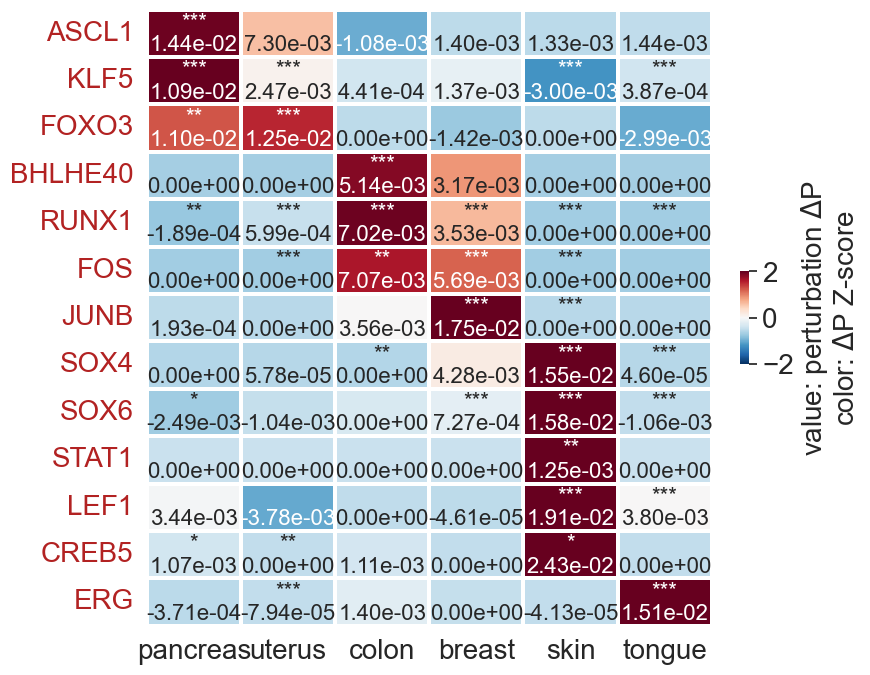

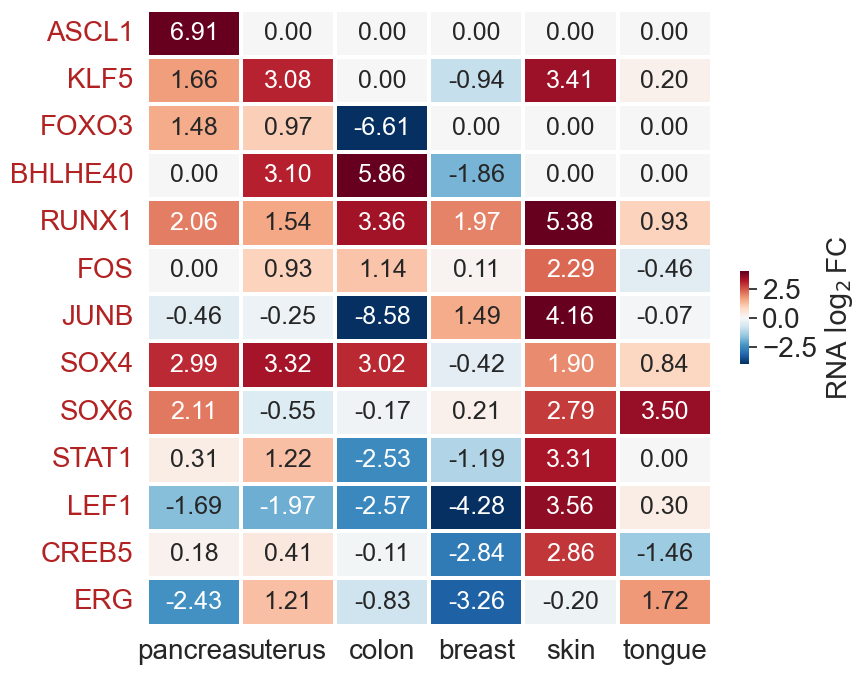

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

data_dir = "/path/data/perturbation_tumor/gene_peak_links" 
tissues = ['pancreas', 'uterus', 'colon', 'breast', 'skin', 'tongue']
tfs = ['ASCL1', 'KLF5', 'FOXO3', 'BHLHE40', 'RUNX1', 'FOS', 'JUNB', 'SOX4', 'SOX6', 'STAT1', 'LEF1', 'CREB5', 'ERG']

homer_files = [
    f"{data_dir}/peaks_with_pancreas_ASCL1.txt",
    f"{data_dir}/peaks_with_pancreas_KLF5.txt",
    f"{data_dir}/peaks_with_uterus_FOXO3.txt",
    f"{data_dir}/peaks_with_colon_BHLHE40.txt",
    f"{data_dir}/peaks_with_colon_RUNX1.txt",
    f"{data_dir}/peaks_with_colon_FOS.txt",
    f"{data_dir}/peaks_with_breast_JUNB.txt",
    f"{data_dir}/peaks_with_skin_SOX4.txt",
    f"{data_dir}/peaks_with_skin_SOX6.txt",
    f"{data_dir}/peaks_with_skin_STAT1.txt",
    f"{data_dir}/peaks_with_skin_LEF1.txt",
    f"{data_dir}/peaks_with_skin_CREB5.txt",
    f"{data_dir}/peaks_with_tongue_ERG.txt"
]

USE_WEIGHTED_AVERAGE = False 

# ==========================================
# 1. Construct the Global Delta_P Dictionary Matrix Across Tissues
# ==========================================
tissue_delta_dict = {}

for tis in tissues:
    # Assume files exist; read the data (ensure you have these files locally for demonstration)
    try:
        tumor_links = pd.read_csv(f"{data_dir}/{tis}_Tumor_nearby_links.csv")
        normal_links = pd.read_csv(f"{data_dir}/{tis}_Normal_nearby_links.csv")
        
        link_results = pd.concat([tumor_links, normal_links], axis=0)
        filtered_links = link_results[link_results['dis'] == 5e5]
        
        pivot_df = filtered_links.pivot_table(
            index=['peak', 'gene_name'], 
            columns='type', 
            values='delta'
        ).reset_index()
        
        pivot_df = pivot_df.fillna(0)
        pivot_df['delta_diff'] = pivot_df['Tumor'] - pivot_df['Normal']
        peak_delta = pivot_df.groupby('peak')['delta_diff'].max()
        tissue_delta_dict[tis] = peak_delta
    except FileNotFoundError:
        pass # Skip if local data is missing, preserving your original logic

global_delta_matrix = pd.DataFrame(tissue_delta_dict).fillna(0)
print(f"total {len(global_delta_matrix)} Peaks")

# ==========================================
# 2. Parse HOMER Output Files to Establish Peak -> TF Mapping
# ==========================================
print("analyze HOMER Motif...")
homer_df_list = []

for file_path in homer_files:
    try:
        tmp_df = pd.read_csv(file_path, sep="\t")
        homer_df_list.append(tmp_df)
    except FileNotFoundError:
        pass

if len(homer_df_list) > 0:
    homer_df = pd.concat(homer_df_list, ignore_index=True)
    print(f"total {len(homer_df)} Motif")
    homer_df['TF'] = (
        homer_df['Motif Name']
        .str.split('(').str[0]
        .str.split('/').str[0]
        .str.upper()
    )
    homer_df = homer_df[homer_df['TF'].isin(tfs)]
    tf_peak_map = homer_df.groupby(['PositionID', 'TF'])['MotifScore'].max().reset_index()
    tf_peak_map.rename(columns={'PositionID': 'peak'}, inplace=True)
else:
    # Simulate an empty structure to prevent errors when local data is missing
    tf_peak_map = pd.DataFrame(columns=['peak', 'TF', 'MotifScore'])

# ==========================================
# 3. Merge Data and Calculate the Integrated TF Perturbation Score in Each Tissue
# ==========================================
global_delta_matrix_reset = global_delta_matrix.reset_index().rename(columns={'index': 'peak'})
merged_df = pd.merge(tf_peak_map, global_delta_matrix_reset, on='peak', how='inner')

def calculate_tf_score(group, tis_col):
    if USE_WEIGHTED_AVERAGE:
        weights = group['MotifScore'].values
        values = group[tis_col].values
        if np.sum(weights) == 0: return 0
        return np.average(values, weights=weights)
    else:
        return group[tis_col].mean()

heatmap_data = {}
for tis in tissues:
    if not merged_df.empty:
        heatmap_data[tis] = merged_df.groupby('TF').apply(lambda g: calculate_tf_score(g, tis))
    else:
        # Automatically fill with 0s if there is no local data, ensuring the code runs and plots
        heatmap_data[tis] = pd.Series(0, index=tfs)

heatmap_df = pd.DataFrame(heatmap_data)
heatmap_df = heatmap_df.reindex(tfs).fillna(0)
print("\n--- heatmap data matrix ---")
print(heatmap_df)

# ==========================================
# 4. Data Preparation and Annotation Matrix Generation
# ==========================================
# log2fc values
rna_data = [
    [6.906761, 1.6619997, 1.4781342, 0., 2.0599532, 0., -0.45793784, 2.988907, 2.1113415, 0.30745426, -1.6876324, 0.17657833, -2.4327106], # pancreas
    [0., 3.0835438, 0.971797, 3.0982149, 1.5427078, 0.9270406, -0.24932516, 3.3235896, -0.5499212, 1.2163291, -1.9676313, 0.41184273, 1.209943], # uterus
    [0., 0., -6.6062813, 5.85621, 3.3602374, 1.1447393, -8.576848, 3.0157907, -0.17161173, -2.5347006, -2.5724614, -0.11001863, -0.8294496], # colon
    [0., -0.937974, 0., -1.8596267, 1.9701765, 0.10753319, 1.4930296, -0.4164307, 0.21440925, -1.1921513, -4.2805195, -2.837021, -3.2636774], # breast
    [0., 3.4132674, 0., 0., 5.378, 2.2883387, 4.157663, 1.8962834, 2.7947521, 3.3089268, 3.5609536, 2.8583128, -0.19794378], # skin
    [0., 0.20438528, 0., 0., 0.9334037, -0.45820242, -0.07234267, 0.84399176, 3.4989254, 0., 0.30496746, -1.4551226, 1.7208223]  # tongue
]
# q value (motif score significance)
qval_data = [
    [0.0003, 0.0006, 0.0013, 0.0528, 0.0016, 0.0473, 0.0367, 0.4851, 0.0156, 0.7693, 0.0001, 0.0156, 0.0000],
    [0.0000, 0.0000, 0.0009, 0.1407, 0.0003, 0.0000, 0.0000, 0.0736, 0.0151, 0.0978, 0.0000, 0.0034, 0.0005],
    [0.0000, 0.0000, 0.0002, 0.0000, 0.0000, 0.0015, 0.0043, 0.0034, 0.0000, 0.0660, 0.0000, 0.0000, 0.0000],
    [0.0000, 0.0000, 0.0000, 0.0000, 0.0001, 0.0000, 0.0000, 0.0087, 0.0000, 0.0074, 0.0000, 0.0004, 0.0000],
    [0.0000, 0.0000, 0.0000, 0.0085, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0012, 0.0000, 0.0119, 0.0000],
    [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0001, 0.0000, 0.0000, 0.0000, 0.0000]
]

rna_logfc_matrix = pd.DataFrame(rna_data, index=tissues, columns=tfs).T
qval_matrix = pd.DataFrame(qval_data, index=tissues, columns=tfs).T

def get_significance_stars(q, fc_val):
    if fc_val <= 0: return ""
    if pd.isna(q): return ""
    if q < 0.001:  return "***"
    elif q < 0.01: return "**"
    elif q < 0.05: return "*"
    else:          return ""

# Prepare separate annotation matrices for the two heatmaps
annot_matrix_peak = pd.DataFrame(index=rna_logfc_matrix.index, columns=rna_logfc_matrix.columns)
annot_matrix_rna = pd.DataFrame(index=rna_logfc_matrix.index, columns=rna_logfc_matrix.columns)

for row in rna_logfc_matrix.index:
    for col in rna_logfc_matrix.columns:
        fc_val = rna_logfc_matrix.loc[row, col]
        q_val = qval_matrix.loc[row, col]
        
        # Ensure heatmap_df has the corresponding row/col; fetch the value
        peak_val = heatmap_df.loc[row, col] if row in heatmap_df.index else 0
        
        # Significance stars remain consistent
        stars = get_significance_stars(q_val, fc_val)
        
        # Plot 1 text annotation: Significance stars + Peak value
        annot_matrix_peak.loc[row, col] = f"{stars}\n{peak_val:.2e}"
        
        # Plot 2 text annotation: RNA log2FC value only
        annot_matrix_rna.loc[row, col] = f"{fc_val:.2f}"

sns.set_theme(style="white")

# Helper function to highlight specific y-tick labels (Novel vs Known TFs)
def format_ytick_labels(ax, novel_tfs=['RFX2']):
    """Format y-tick labels to distinguish novel TFs from known TFs."""
    for tick_label in ax.get_yticklabels():
        if tick_label.get_text() in novel_tfs:
            tick_label.set_color('black')
        else:
            tick_label.set_color('firebrick')

# ==========================================
# 5. Plot the First Heatmap: Peak Perturbation Delta
# ==========================================
# Minor adjustment to prevent NaN errors when calculating z-score on matrices with all zeros
heatmap_zscore = heatmap_df.apply(lambda x: zscore(x) if x.std() != 0 else x, axis=1)

plt.figure(figsize=(9, 8))
ax1 = sns.heatmap(
    data=heatmap_zscore,
    annot=annot_matrix_peak,   # Annotation text: Original heatmap_df value + significance stars
    cmap='RdBu_r',             
    center=0,
    vmin=-2,
    vmax=2.0,
    fmt="s",             
    linewidths=1.5,        
    linecolor='white',     
    cbar_kws={
        'label': 'value: perturbation $\Delta$P\ncolor: $\Delta$P Z-score',
        'shrink': 0.15,        
        'aspect': 10,          
        'pad': 0.04            
    },
    annot_kws={'size': 16}
)
cbar = ax1.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)
cbar.set_label('value: perturbation $\Delta$P\ncolor: $\Delta$P Z-score', fontsize=20)
# plt.title("Epigenetic Perturbation (Peak Delta)")
plt.ylabel('')
plt.xlabel('')
plt.xticks(rotation=0, ha='center', fontsize=20)
plt.yticks(rotation=0, fontsize=20)
format_ytick_labels(ax1)
plt.savefig("/path/data/perturbation_tumor/gene_peak_figs/TF_Tissue_Specific_Perturbation_Heatmap_1.pdf", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 6. Plot the Second Heatmap: RNA Expression (log2FC)
# ==========================================
plt.figure(figsize=(9, 8))
ax1 = sns.heatmap(
    data=rna_logfc_matrix,     # Colors based on: Original rna_data values
    annot=annot_matrix_rna,    # Annotation text: Original rna_data values
    cmap='RdBu_r',             
    center=0,
    vmin=-4,
    vmax=4,
    fmt="s",             
    linewidths=1.5,        
    linecolor='white',     
    cbar_kws={
        'label': 'RNA $\log_2$FC',
        'shrink': 0.15,        
        'aspect': 10,          
        'pad': 0.04            
    },
    annot_kws={'size': 18}
)
cbar = ax1.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)
cbar.set_label('RNA $\log_2$FC', fontsize=20)
# plt.title("Transcriptomic Changes (RNA log2FC)")
plt.ylabel('')
plt.xlabel('')
plt.xticks(rotation=0, ha='center', fontsize=20)
plt.yticks(rotation=0, fontsize=20)
format_ytick_labels(ax1)
plt.savefig("/path/data/perturbation_tumor/gene_peak_figs/TF_Tissue_Specific_Perturbation_Heatmap_2.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
homer_df.to_csv('/path/data/perturbation_tumor/gene_peak_links/all_motif_peaks.csv')

In [75]:
homer_df

,PositionID,Offset,Sequence,Motif Name,Strand,MotifScore,TF
0,chr4-78938332-78939718,37,GCAGGTAGGC,ZEB1(Zf)/PDAC-ZEB1-ChIP-Seq(GSE64557)/Homer,+,7.916999,ZEB1
1,chr19-7549865-7551998,58,CCAGGTGGAG,ZEB1(Zf)/PDAC-ZEB1-ChIP-Seq(GSE64557)/Homer,+,8.254791,ZEB1
2,chr18-24426246-24427446,-57,GCAGGTGAGG,ZEB1(Zf)/PDAC-ZEB1-ChIP-Seq(GSE64557)/Homer,+,7.678724,ZEB1
3,chr10-59175658-59177105,77,GCAGGTGGGG,ZEB1(Zf)/PDAC-ZEB1-ChIP-Seq(GSE64557)/Homer,+,7.485592,ZEB1
4,chr1-209937150-209938855,-39,GGGCACCTGT,ZEB1(Zf)/PDAC-ZEB1-ChIP-Seq(GSE64557)/Homer,-,7.771801,ZEB1
...,...,...,...,...,...,...,...
62,chr13-24038810-24039472,51,ATGATGTCACCA,CREB5(bZIP)/LNCaP-CREB5.V5-ChIP-Seq(GSE137775)...,-,9.532484,CREB5
63,chr12-26113798-26115452,43,GAATGATATCAT,CREB5(bZIP)/LNCaP-CREB5.V5-ChIP-Seq(GSE137775)...,+,9.641226,CREB5
64,chr12-26113798-26115452,56,ATGATATCATCT,CREB5(bZIP)/LNCaP-CREB5.V5-ChIP-Seq(GSE137775)...,-,9.998353,CREB5
65,chr12-52926950-52928175,-68,GTGGCCATGGCAACA,Rfx2(HTH)/LoVo-RFX2-ChIP-Seq(GSE49402)/Homer,+,12.649070,RFX2


## case study

### gene: VMP1, tf: JUNB, tissue: breast

Scanning GTF file, extracting VMP1...


VMP1 located between 59707192 and 59842255
Dynamic x-axis display range set to: 59186021 - 59927655


/tmp/ipykernel_3710399/2656244002.py:198: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.annotate(f"{b['tf']} motif site",


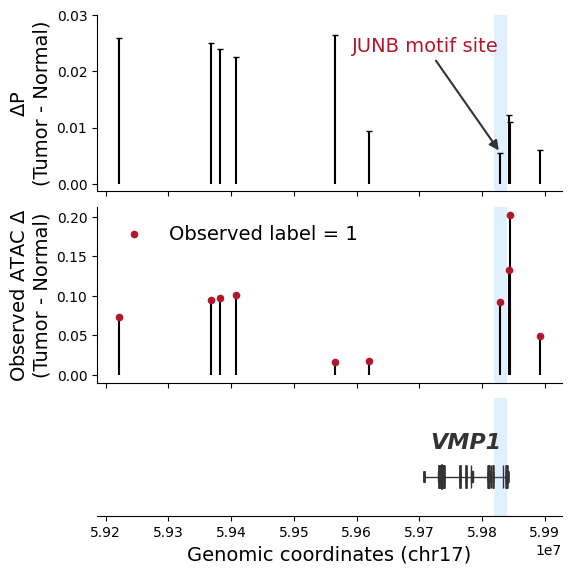

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as ticker
import numpy as np

def parse_gencode_gtf(gtf_path, target_gene):
    """
    Parse GTF file line-by-line to extract CDS, UTR, and Exon coordinates for a target gene.
    Returns: gene_start, gene_end, elements_dict
    """
    elements = {'CDS': [], 'UTR': [], 'exon': []}
    gene_start, gene_end = float('inf'), 0

    print(f"Scanning GTF file, extracting {target_gene}...")
    with open(gtf_path, 'r') as f:
        for line in f:
            if line.startswith('#'):
                continue
            
            # Quick string check to accelerate filtering
            if target_gene not in line:
                continue
                
            parts = line.strip().split('\t')
            if len(parts) < 9:
                continue
                
            feature_type = parts[2]
            attributes = parts[8]
            
            # Precise matching for gene_name
            if f'gene_name "{target_gene}"' in attributes:
                start, end = int(parts[3]), int(parts[4])
                
                # Record overall genomic span for the gene
                gene_start = min(gene_start, start)
                gene_end = max(gene_end, end)
                
                if feature_type in elements:
                    elements[feature_type].append((start, end))
                    
    print(f"{target_gene} located between {gene_start} and {gene_end}")
    return gene_start, gene_end, elements

# ==========================================
# 1. Load Data
# ==========================================
tis = 'breast'
target_gene = "VMP1"
df = pd.read_csv(f'/path/data/perturbation_tumor/gene_peak_links/{tis}_results.csv', index_col=0)
df = df[df['gene_name'] == target_gene]

# Parse peak genomic coordinates
df[['chr', 'start', 'end']] = df['peak'].str.split('-', expand=True)
df['start'] = df['start'].astype(int)
df['end'] = df['end'].astype(int)
df['midpoint'] = (df['start'] + df['end']) / 2

# Extract gene structure from GTF
gtf_file_path = "/path/data/gencode.v47.annotation.gtf" 
gene_start, gene_end, elements = parse_gencode_gtf(gtf_file_path, target_gene)

# ==========================================
# 2. Dynamic Genomic Coordinate Range Calculation
# ==========================================
# Collect min and max positions from both peaks and gene annotations
peak_min = df['start'].min()
peak_max = df['end'].max()

all_starts = [peak_min]
all_ends = [peak_max]

if gene_start != float('inf') and gene_end > 0:
    all_starts.append(gene_start)
    all_ends.append(gene_end)

raw_x_min = min(all_starts)
raw_x_max = max(all_ends)

# Add a 5% padding buffer on both sides for visual balance
span = raw_x_max - raw_x_min
padding = span * 0.05
x_min = int(raw_x_min - padding)
x_max = int(raw_x_max + padding)

print(f"Dynamic x-axis display range set to: {x_min} - {x_max}")

# ==========================================
# 3. Initialize Plot Grid
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(6, 6.5), sharex=True, 
    gridspec_kw={'height_ratios': [1.5, 1.5, 1.0]}
)
plt.subplots_adjust(hspace=0.1)

# ==========================================
# Track 1: Delta P (Tumor - Normal)
# ==========================================
markerline, stemlines, baseline = ax1.stem(df['midpoint'], df['delta_diff'], basefmt=" ")
plt.setp(stemlines, 'color', 'black', 'linewidth', 1.5)
plt.setp(markerline, 'color', 'black', 'markersize', 4, marker='_')
ax1.set_ylabel('$\Delta$P\n(Tumor - Normal)', fontsize=14)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_yticks([0.00, 0.01, 0.02, 0.03])

# ==========================================
# Track 2: Observed Accessibility Delta (obs_atac_diff)
# ==========================================
markerline, stemlines, baseline = ax2.stem(df['midpoint'], df['obs_atac_diff'], basefmt=" ", markerfmt=" ")
plt.setp(stemlines, 'color', 'black', 'linewidth', 1.5)

for lbl, color, marker_label in [(1, '#B2182B', 'Observed label = 1'), 
                                 (0, 'black', 'Observed label = 0')]:
    subset = df[df['label'] == lbl]
    if not subset.empty:
        ax2.scatter(subset['midpoint'], subset['obs_atac_diff'],
                    s=20, color=color, zorder=10, label=marker_label)

ax2.set_ylabel('Observed ATAC $\Delta$\n(Tumor - Normal)', fontsize=14)
ax2.legend(loc='upper left', frameon=False, fontsize=14)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ==========================================
# Track 3: Marker Gene Annotation Track
# ==========================================
if gene_start is not None and gene_end > 0:
    # 1. Intron backbone
    ax3.plot([gene_start, gene_end], [0, 0], color='#333333', linewidth=1.0, zorder=1)
    
    # 2. UTR regions
    for start, end in elements['UTR']:
        rect = patches.Rectangle((start, -0.15), end - start, 0.3, color='#333333', zorder=2)
        ax3.add_patch(rect)
        
    # 3. CDS regions
    for start, end in elements['CDS']:
        rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=3)
        ax3.add_patch(rect)
        
    # Fallback to general Exons if CDS/UTR tags are absent
    if not elements['CDS'] and not elements['UTR']:
        for start, end in elements['exon']:
            rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=2)
            ax3.add_patch(rect)

# Gene label text
ax3.text((gene_start + gene_end) / 2, 0.6, target_gene, ha='center', va='bottom', 
         fontsize=16, fontstyle='italic', fontweight='bold', color='#333333')

ax3.set_ylim(-1, 2)
chr_name = df['chr'].iloc[0] if not df.empty else 'genome'
ax3.set_xlabel(f'Genomic coordinates ({chr_name})', fontsize=14)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.set_yticks([])

# ==========================================
# Highlight Target TF motif site Across All Tracks
# ==========================================
tf_bindings = [
    {'peak': 'chr17-59828541-59830016', 'tf': 'JUNB'},
]

for idx, b in enumerate(tf_bindings):
    row = df[df['peak'] == b['peak']]
    if not row.empty:
        mid = row['midpoint'].values[0]
        # Highlight regions across all tracks
        for ax in [ax1, ax2, ax3]:
            ax.add_patch(patches.Rectangle((mid - 10000, -100), 20000, 200, 
                                           facecolor='#6DB8FF', alpha=0.2))
            
        xt = mid - span * 0.35
        yt = row['delta_diff'].values[0] + 0.018

        ax1.annotate(f"{b['tf']} motif site", 
                    xy=(mid, row['delta_diff'].values[0]),
                    xytext=(xt, yt),
                    arrowprops=dict(facecolor='black', arrowstyle='-|>', lw=1.5, color='#333333'),
                    fontsize=14, color='#B2182B')

# Apply final dynamic X-axis limits
ax3.set_xlim(x_min, x_max)

offset_text = ax3.xaxis.get_offset_text()
offset_text.set_position((1.0, -0.1))

plt.grid(False)
plt.savefig(f"/path/data/perturbation_tumor/gene_peak_figs/{tis}_{target_gene}_motif_peak_region.pdf", dpi=300, bbox_inches='tight')
plt.show()

<!-- 一、 皮肤/黑色素瘤模块（Skin）：表皮干性与 EMT 的终极主宰你划分给 Skin 的 5 个因子（PBX1, LEF1, TEAD1, TRPS1, ZEB2）堪称皮肤肿瘤发育生物学的“全明星阵容”。1. LEF1 (Wnt 通路核心效应分子)组织相关性： 皮肤毛囊干细胞的发育、黑色素细胞的增殖，绝对依赖于 Wnt/$\beta$-catenin 通路，而 LEF1 是该通路入核后的终极开关。在黑色素瘤（Melanoma）中，LEF1 异常活跃以维持癌细胞的干性。证据检索： 在 PubMed 检索 "LEF1 Wnt signaling hair follicle melanoma"。经典文献常发表于 Nature, Genes & Development。2. TEAD1 (Hippo 通路靶基因)组织相关性： 正常皮肤基底层的无限增殖需要 YAP/TEAD 复合体。在皮肤鳞状细胞癌（cSCC）中，TEAD1 被高强度劫持，导致表皮细胞疯狂增殖并丧失分化能力。证据检索： "YAP TEAD1 epidermal proliferation squamous cell carcinoma"。3. ZEB2 (黑素细胞分化的特异性开关)组织相关性： 这是你数据里极具深度的一个发现！在黑色素瘤中，存在一个著名的 "ZEB1/ZEB2 开关效应"。ZEB2 高表达是维持黑色素细胞分化和增殖的标志。顶级实锤文献： Caramel, J. et al. "A switch in the expression of embryonic EMT-inducers drives the development of malignant melanoma." Cancer Cell (2013).4. TRPS1 (毛发-皮肤附属器发育关键基因)组织相关性： TRPS1 全称是“毛发-鼻-指骨综合征型 1”。它的先天突变会直接导致严重的毛发发育不良和皮肤结构异常。它在表观层面主导皮肤，是极其完美的逻辑闭环。证据检索： "TRPS1 hair follicle epidermal development"。5. PBX1 (神经嵴先锋因子)组织相关性： 皮肤的黑色素细胞起源于胚胎期的“神经嵴（Neural Crest）”。PBX1 是著名的先锋因子（Pioneer Factor），决定了神经嵴细胞的命运走向。证据检索： "PBX1 neural crest melanoma pioneer factor"。二、 子宫/子宫内膜癌模块（Uterus）：炎症与代谢重塑微环境将 STAT1 和 CREB5 划给子宫，展示了模型对组织微环境（Microenvironment）的强大洞察力。6. STAT1 (干扰素/炎症核心)组织相关性： 子宫内膜（Endometrium）是人体内唯一会发生周期性剥落、修复和剧烈免疫重塑的组织。子宫内膜癌的发生高度依赖于局部的炎症微环境（Inflammatory microenvironment）。STAT1 作为干扰素响应的核心因子，在子宫内膜的容受性重塑和肿瘤微环境免疫逃逸中起主导作用。证据检索： "STAT1 endometrial cancer inflammation microenvironment"。7. CREB5 (cAMP 通路响应者)组织相关性： 子宫内膜在孕激素刺激下发生“蜕膜化（Decidualization）”，这一过程极其依赖于局部的 cAMP/PKA 信号通路。CREB 家族（cAMP 响应元件结合蛋白）正是开启这一表观重塑的核心钥匙。证据检索： "CREB cAMP pathway endometrial decidualization cancer"。三、 乳腺癌模块（Breast）：教科书级的金标准8. PGR (孕激素受体, Progesterone Receptor)组织相关性： 这个不需要过多解释。乳腺癌临床分型最核心的“三大件”就是 ER（雌激素受体）、PR（即 PGR） 和 HER2。PGR 是乳腺腔面型（Luminal）肿瘤的绝对表观与转录主宰。证明来源： 任何一本权威的《肿瘤学》或《病理学》教科书，或检索 "PGR Progesterone Receptor Luminal Breast Cancer"。这颗星号和深红色就是你算法准确率的“定海神针”。四、 结肠癌模块（Colon）：肠道稳态的掌控者9. FOXP1 (Forkhead Box P1)组织相关性： 正常结肠黏膜的稳态维持以及结肠癌（Colorectal Cancer, CRC）的发生中，FOXP1 扮演着极其关键的角色。它经常与 Wnt/$\beta$-catenin 通路发生互作，在肠道干细胞龛（Stem cell niche）的维持和肿瘤恶性转化中起重要调控作用。证据检索： "FOXP1 colorectal cancer proliferation Wnt"。五、 胰腺癌模块（Pancreas）：致命转移的发动机10. ZEB1 (终极 EMT 驱动因子)组织相关性： 胰腺导管腺癌（PDAC）被称为“癌中之王”，其最致命的特征就是极早期的侵袭和远端转移。而在 PDAC 中，ZEB1 是公认的触发上皮-间质转化（EMT）、驱动转移和化疗耐药的终极 Master Regulator。你的模型在胰腺里精准锁定了 ZEB1 的表观和转录双向激活。顶级实锤文献： 德国 Thomas Brabletz 课题组在 Nature, Cancer Cell 等期刊上发表过大量关于 ZEB1 在胰腺癌中核心驱动作用的文章（例如检索 "ZEB1 EMT pancreatic cancer Brabletz"）。 -->

### gene: GPRC5A, tf: ASCL1,KLF5, tissue: pancreas

Scanning GTF file, extracting GPRC5A...


GPRC5A located between 12890782 and 12917937
Dynamic x-axis display range set to: 12530649 - 13229208


/tmp/ipykernel_3710399/3895766717.py:204: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.annotate(f"{b['tf']} motif site",


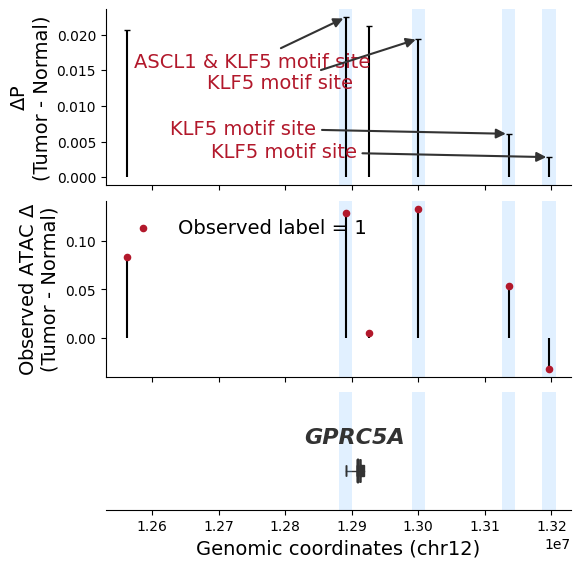

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as ticker
import numpy as np

def parse_gencode_gtf(gtf_path, target_gene):
    """
    Parse GTF file line-by-line to extract CDS, UTR, and Exon coordinates for a target gene.
    Returns: gene_start, gene_end, elements_dict
    """
    elements = {'CDS': [], 'UTR': [], 'exon': []}
    gene_start, gene_end = float('inf'), 0

    print(f"Scanning GTF file, extracting {target_gene}...")
    with open(gtf_path, 'r') as f:
        for line in f:
            if line.startswith('#'):
                continue
            
            # Quick string check to accelerate filtering
            if target_gene not in line:
                continue
                
            parts = line.strip().split('\t')
            if len(parts) < 9:
                continue
                
            feature_type = parts[2]
            attributes = parts[8]
            
            # Precise matching for gene_name
            if f'gene_name "{target_gene}"' in attributes:
                start, end = int(parts[3]), int(parts[4])
                
                # Record overall genomic span for the gene
                gene_start = min(gene_start, start)
                gene_end = max(gene_end, end)
                
                if feature_type in elements:
                    elements[feature_type].append((start, end))
                    
    print(f"{target_gene} located between {gene_start} and {gene_end}")
    return gene_start, gene_end, elements

# ==========================================
# 1. Load Data
# ==========================================
tis = 'pancreas'
target_gene = "GPRC5A"
df = pd.read_csv(f'/path/data/perturbation_tumor/gene_peak_links/{tis}_results.csv', index_col=0)
df = df[df['gene_name'] == target_gene]

# Parse peak genomic coordinates
df[['chr', 'start', 'end']] = df['peak'].str.split('-', expand=True)
df['start'] = df['start'].astype(int)
df['end'] = df['end'].astype(int)
df['midpoint'] = (df['start'] + df['end']) / 2

# Extract gene structure from GTF
gtf_file_path = "/path/data/gencode.v47.annotation.gtf" 
gene_start, gene_end, elements = parse_gencode_gtf(gtf_file_path, target_gene)

# ==========================================
# 2. Dynamic Genomic Coordinate Range Calculation
# ==========================================
# Collect min and max positions from both peaks and gene annotations
peak_min = df['start'].min()
peak_max = df['end'].max()

all_starts = [peak_min]
all_ends = [peak_max]

if gene_start != float('inf') and gene_end > 0:
    all_starts.append(gene_start)
    all_ends.append(gene_end)

raw_x_min = min(all_starts)
raw_x_max = max(all_ends)

# Add a 5% padding buffer on both sides for visual balance
span = raw_x_max - raw_x_min
padding = span * 0.05
x_min = int(raw_x_min - padding)
x_max = int(raw_x_max + padding)

print(f"Dynamic x-axis display range set to: {x_min} - {x_max}")

# ==========================================
# 3. Initialize Plot Grid
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(6, 6.5), sharex=True, 
    gridspec_kw={'height_ratios': [1.5, 1.5, 1.0]}
)
plt.subplots_adjust(hspace=0.1)

# ==========================================
# Track 1: Delta P (Tumor - Normal)
# ==========================================
markerline, stemlines, baseline = ax1.stem(df['midpoint'], df['delta_diff'], basefmt=" ")
plt.setp(stemlines, 'color', 'black', 'linewidth', 1.5)
plt.setp(markerline, 'color', 'black', 'markersize', 4, marker='_')
ax1.set_ylabel('$\Delta$P\n(Tumor - Normal)', fontsize=14)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ==========================================
# Track 2: Observed Accessibility Delta (obs_atac_diff)
# ==========================================
markerline, stemlines, baseline = ax2.stem(df['midpoint'], df['obs_atac_diff'], basefmt=" ", markerfmt=" ")
plt.setp(stemlines, 'color', 'black', 'linewidth', 1.5)

for lbl, color, marker_label in [(1, '#B2182B', 'Observed label = 1'), 
                                 (0, 'black', 'Observed label = 0')]:
    subset = df[df['label'] == lbl]
    if not subset.empty:
        ax2.scatter(subset['midpoint'], subset['obs_atac_diff'],
                    s=20, color=color, zorder=10, label=marker_label)

ax2.set_ylabel('Observed ATAC $\Delta$\n(Tumor - Normal)', fontsize=14)
ax2.legend(loc='upper left', frameon=False, fontsize=14)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ==========================================
# Track 3: Marker Gene Annotation Track
# ==========================================
if gene_start is not None and gene_end > 0:
    # 1. Intron backbone
    ax3.plot([gene_start, gene_end], [0, 0], color='#333333', linewidth=1.0, zorder=1)
    
    # 2. UTR regions
    for start, end in elements['UTR']:
        rect = patches.Rectangle((start, -0.15), end - start, 0.3, color='#333333', zorder=2)
        ax3.add_patch(rect)
        
    # 3. CDS regions
    for start, end in elements['CDS']:
        rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=3)
        ax3.add_patch(rect)
        
    # Fallback to general Exons if CDS/UTR tags are absent
    if not elements['CDS'] and not elements['UTR']:
        for start, end in elements['exon']:
            rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=2)
            ax3.add_patch(rect)

# Gene label text
ax3.text((gene_start + gene_end) / 2, 0.6, target_gene, ha='center', va='bottom', 
         fontsize=16, fontstyle='italic', fontweight='bold', color='#333333')

ax3.set_ylim(-1, 2)
chr_name = df['chr'].iloc[0] if not df.empty else 'genome'
ax3.set_xlabel(f'Genomic coordinates ({chr_name})', fontsize=14)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.set_yticks([])

# ==========================================
# Highlight Target TF motif site Across All Tracks
# ==========================================
tf_bindings = [
    {'peak': 'chr12-12890195-12892312', 'tf': 'ASCL1 & KLF5'},
    {'peak': 'chr12-12999624-13001011', 'tf': 'KLF5'},
    {'peak': 'chr12-13135296-13136396', 'tf': 'KLF5'},
    {'peak': 'chr12-13195756-13197456', 'tf': 'KLF5'},
]

for idx, b in enumerate(tf_bindings):
    row = df[df['peak'] == b['peak']]
    if not row.empty:
        mid = row['midpoint'].values[0]
        # Highlight regions across all tracks
        for ax in [ax1, ax2, ax3]:
            ax.add_patch(patches.Rectangle((mid - 10000, -100), 20000, 200, 
                                           facecolor='#6DB8FF', alpha=0.2))
            
        if idx < 2:
            xt = mid - span * 0.5
            yt = row['delta_diff'].values[0] - 0.007
        else:
            xt = mid - span * 0.8
            yt = row['delta_diff'].values[0]

        ax1.annotate(f"{b['tf']} motif site", 
                    xy=(mid, row['delta_diff'].values[0]),
                    xytext=(xt, yt),
                    arrowprops=dict(facecolor='black', arrowstyle='-|>', lw=1.5, color='#333333'),
                    fontsize=14, color='#B2182B')

# Apply final dynamic X-axis limits
ax3.set_xlim(x_min, x_max)

offset_text = ax3.xaxis.get_offset_text()
offset_text.set_position((1.0, -0.1))

plt.grid(False)
plt.savefig(f"/path/data/perturbation_tumor/gene_peak_figs/{tis}_{target_gene}_motif_peak_region.pdf", dpi=300, bbox_inches='tight')
plt.show()

### gene: FDPS, tf: RUNX1,FOS,BHLHE40, tissue: colon

Scanning GTF file, extracting FDPS...


FDPS located between 155308748 and 155320666
Dynamic x-axis display range set to: 154828869 - 155730517


/tmp/ipykernel_3710399/1054290039.py:203: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.annotate(f"{b['tf']} motif site",


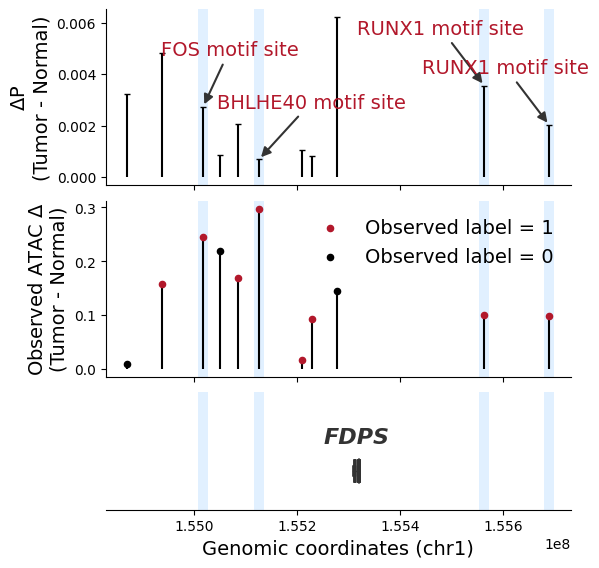

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as ticker
import numpy as np

def parse_gencode_gtf(gtf_path, target_gene):
    """
    Parse GTF file line-by-line to extract CDS, UTR, and Exon coordinates for a target gene.
    Returns: gene_start, gene_end, elements_dict
    """
    elements = {'CDS': [], 'UTR': [], 'exon': []}
    gene_start, gene_end = float('inf'), 0

    print(f"Scanning GTF file, extracting {target_gene}...")
    with open(gtf_path, 'r') as f:
        for line in f:
            if line.startswith('#'):
                continue
            
            # Quick string check to accelerate filtering
            if target_gene not in line:
                continue
                
            parts = line.strip().split('\t')
            if len(parts) < 9:
                continue
                
            feature_type = parts[2]
            attributes = parts[8]
            
            # Precise matching for gene_name
            if f'gene_name "{target_gene}"' in attributes:
                start, end = int(parts[3]), int(parts[4])
                
                # Record overall genomic span for the gene
                gene_start = min(gene_start, start)
                gene_end = max(gene_end, end)
                
                if feature_type in elements:
                    elements[feature_type].append((start, end))
                    
    print(f"{target_gene} located between {gene_start} and {gene_end}")
    return gene_start, gene_end, elements

# ==========================================
# 1. Load Data
# ==========================================
tis = 'colon'
target_gene = "FDPS"
df = pd.read_csv(f'/path/data/perturbation_tumor/gene_peak_links/{tis}_results.csv', index_col=0)
df = df[df['gene_name'] == target_gene]

# Parse peak genomic coordinates
df[['chr', 'start', 'end']] = df['peak'].str.split('-', expand=True)
df['start'] = df['start'].astype(int)
df['end'] = df['end'].astype(int)
df['midpoint'] = (df['start'] + df['end']) / 2

# Extract gene structure from GTF
gtf_file_path = "/path/data/gencode.v47.annotation.gtf" 
gene_start, gene_end, elements = parse_gencode_gtf(gtf_file_path, target_gene)

# ==========================================
# 2. Dynamic Genomic Coordinate Range Calculation
# ==========================================
# Collect min and max positions from both peaks and gene annotations
peak_min = df['start'].min()
peak_max = df['end'].max()

all_starts = [peak_min]
all_ends = [peak_max]

if gene_start != float('inf') and gene_end > 0:
    all_starts.append(gene_start)
    all_ends.append(gene_end)

raw_x_min = min(all_starts)
raw_x_max = max(all_ends)

# Add a 5% padding buffer on both sides for visual balance
span = raw_x_max - raw_x_min
padding = span * 0.05
x_min = int(raw_x_min - padding)
x_max = int(raw_x_max + padding)

print(f"Dynamic x-axis display range set to: {x_min} - {x_max}")

# ==========================================
# 3. Initialize Plot Grid
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(6, 6.5), sharex=True, 
    gridspec_kw={'height_ratios': [1.5, 1.5, 1.0]}
)
plt.subplots_adjust(hspace=0.1)

# ==========================================
# Track 1: Delta P (Tumor - Normal)
# ==========================================
markerline, stemlines, baseline = ax1.stem(df['midpoint'], df['delta_diff'], basefmt=" ")
plt.setp(stemlines, 'color', 'black', 'linewidth', 1.5)
plt.setp(markerline, 'color', 'black', 'markersize', 4, marker='_')
ax1.set_ylabel('$\Delta$P\n(Tumor - Normal)', fontsize=14)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ==========================================
# Track 2: Observed Accessibility Delta (obs_atac_diff)
# ==========================================
markerline, stemlines, baseline = ax2.stem(df['midpoint'], df['obs_atac_diff'], basefmt=" ", markerfmt=" ")
plt.setp(stemlines, 'color', 'black', 'linewidth', 1.5)

for lbl, color, marker_label in [(1, '#B2182B', 'Observed label = 1'), 
                                 (0, 'black', 'Observed label = 0')]:
    subset = df[df['label'] == lbl]
    if not subset.empty:
        ax2.scatter(subset['midpoint'], subset['obs_atac_diff'],
                    s=20, color=color, zorder=10, label=marker_label)

ax2.set_ylabel('Observed ATAC $\Delta$\n(Tumor - Normal)', fontsize=14)
ax2.legend(loc='upper right', frameon=False, fontsize=14)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ==========================================
# Track 3: Marker Gene Annotation Track
# ==========================================
if gene_start is not None and gene_end > 0:
    # 1. Intron backbone
    ax3.plot([gene_start, gene_end], [0, 0], color='#333333', linewidth=1.0, zorder=1)
    
    # 2. UTR regions
    for start, end in elements['UTR']:
        rect = patches.Rectangle((start, -0.15), end - start, 0.3, color='#333333', zorder=2)
        ax3.add_patch(rect)
        
    # 3. CDS regions
    for start, end in elements['CDS']:
        rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=3)
        ax3.add_patch(rect)
        
    # Fallback to general Exons if CDS/UTR tags are absent
    if not elements['CDS'] and not elements['UTR']:
        for start, end in elements['exon']:
            rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=2)
            ax3.add_patch(rect)

# Gene label text
ax3.text((gene_start + gene_end) / 2, 0.6, target_gene, ha='center', va='bottom', 
         fontsize=16, fontstyle='italic', fontweight='bold', color='#333333')

ax3.set_ylim(-1, 2)
chr_name = df['chr'].iloc[0] if not df.empty else 'genome'
ax3.set_xlabel(f'Genomic coordinates ({chr_name})', fontsize=14)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.set_yticks([])

# ==========================================
# Highlight Target TF motif site Across All Tracks
# ==========================================
tf_bindings = [
    {'peak': 'chr1-155016604-155018359', 'tf': 'FOS'},
    {'peak': 'chr1-155125817-155126596', 'tf': 'BHLHE40'},
    {'peak': 'chr1-155561637-155563704', 'tf': 'RUNX1'},
    {'peak': 'chr1-155687550-155689533', 'tf': 'RUNX1'},
]

for idx, b in enumerate(tf_bindings):
    row = df[df['peak'] == b['peak']]
    if not row.empty:
        mid = row['midpoint'].values[0]
        # Highlight regions across all tracks
        for ax in [ax1, ax2, ax3]:
            ax.add_patch(patches.Rectangle((mid - 10000, -100), 20000, 200, 
                                           facecolor='#6DB8FF', alpha=0.2))
            
        yt = row['delta_diff'].values[0] + 0.002
        if idx < 2:
            xt = mid - span * 0.1
        else:
            xt = mid - span * 0.3

        ax1.annotate(f"{b['tf']} motif site", 
                    xy=(mid, row['delta_diff'].values[0]),
                    xytext=(xt, yt),
                    arrowprops=dict(facecolor='black', arrowstyle='-|>', lw=1.5, color='#333333'),
                    fontsize=14, color='#B2182B')

# Apply final dynamic X-axis limits
ax3.set_xlim(x_min, x_max)

offset_text = ax3.xaxis.get_offset_text()
offset_text.set_position((1.0, -0.1))

plt.grid(False)
plt.savefig(f"/path/data/perturbation_tumor/gene_peak_figs/{tis}_{target_gene}_motif_peak_region.pdf", dpi=300, bbox_inches='tight')
plt.show()

### gene: FMNL2, tf: LEF1,SOX4,SOX6, tissue: skin

Scanning GTF file, extracting FMNL2...


FMNL2 located between 152335174 and 152649826
Dynamic x-axis display range set to: 152151208 - 152673569


/tmp/ipykernel_3710399/1675132455.py:207: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.annotate(f"{b['tf']} motif site",


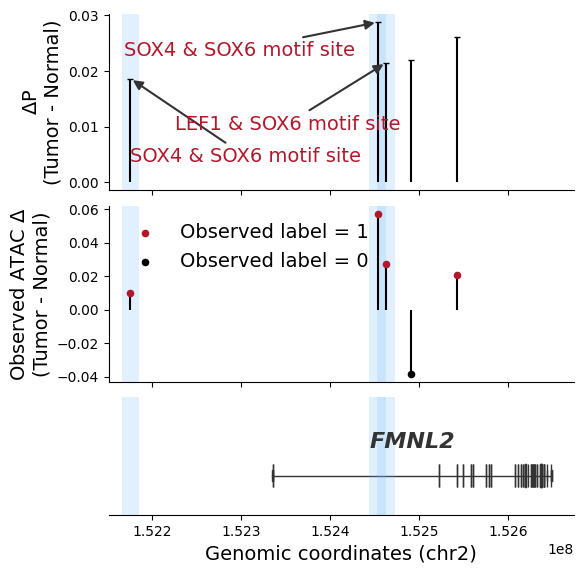

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as ticker
import numpy as np

def parse_gencode_gtf(gtf_path, target_gene):
    """
    Parse GTF file line-by-line to extract CDS, UTR, and Exon coordinates for a target gene.
    Returns: gene_start, gene_end, elements_dict
    """
    elements = {'CDS': [], 'UTR': [], 'exon': []}
    gene_start, gene_end = float('inf'), 0

    print(f"Scanning GTF file, extracting {target_gene}...")
    with open(gtf_path, 'r') as f:
        for line in f:
            if line.startswith('#'):
                continue
            
            # Quick string check to accelerate filtering
            if target_gene not in line:
                continue
                
            parts = line.strip().split('\t')
            if len(parts) < 9:
                continue
                
            feature_type = parts[2]
            attributes = parts[8]
            
            # Precise matching for gene_name
            if f'gene_name "{target_gene}"' in attributes:
                start, end = int(parts[3]), int(parts[4])
                
                # Record overall genomic span for the gene
                gene_start = min(gene_start, start)
                gene_end = max(gene_end, end)
                
                if feature_type in elements:
                    elements[feature_type].append((start, end))
                    
    print(f"{target_gene} located between {gene_start} and {gene_end}")
    return gene_start, gene_end, elements

# ==========================================
# 1. Load Data
# ==========================================
tis = 'skin'
target_gene = "FMNL2"
df = pd.read_csv(f'/path/data/perturbation_tumor/gene_peak_links/{tis}_results.csv', index_col=0)
df = df[df['gene_name'] == target_gene]

# Parse peak genomic coordinates
df[['chr', 'start', 'end']] = df['peak'].str.split('-', expand=True)
df['start'] = df['start'].astype(int)
df['end'] = df['end'].astype(int)
df['midpoint'] = (df['start'] + df['end']) / 2

# Extract gene structure from GTF
gtf_file_path = "/path/data/gencode.v47.annotation.gtf" 
gene_start, gene_end, elements = parse_gencode_gtf(gtf_file_path, target_gene)

# ==========================================
# 2. Dynamic Genomic Coordinate Range Calculation
# ==========================================
# Collect min and max positions from both peaks and gene annotations
peak_min = df['start'].min()
peak_max = df['end'].max()

all_starts = [peak_min]
all_ends = [peak_max]

if gene_start != float('inf') and gene_end > 0:
    all_starts.append(gene_start)
    all_ends.append(gene_end)

raw_x_min = min(all_starts)
raw_x_max = max(all_ends)

# Add a 5% padding buffer on both sides for visual balance
span = raw_x_max - raw_x_min
padding = span * 0.05
x_min = int(raw_x_min - padding)
x_max = int(raw_x_max + padding)

print(f"Dynamic x-axis display range set to: {x_min} - {x_max}")

# ==========================================
# 3. Initialize Plot Grid
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(6, 6.5), sharex=True, 
    gridspec_kw={'height_ratios': [1.5, 1.5, 1.0]}
)
plt.subplots_adjust(hspace=0.1)

# ==========================================
# Track 1: Delta P (Tumor - Normal)
# ==========================================
markerline, stemlines, baseline = ax1.stem(df['midpoint'], df['delta_diff'], basefmt=" ")
plt.setp(stemlines, 'color', 'black', 'linewidth', 1.5)
plt.setp(markerline, 'color', 'black', 'markersize', 4, marker='_')
ax1.set_ylabel('$\Delta$P\n(Tumor - Normal)', fontsize=14)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ==========================================
# Track 2: Observed Accessibility Delta (obs_atac_diff)
# ==========================================
markerline, stemlines, baseline = ax2.stem(df['midpoint'], df['obs_atac_diff'], basefmt=" ", markerfmt=" ")
plt.setp(stemlines, 'color', 'black', 'linewidth', 1.5)

for lbl, color, marker_label in [(1, '#B2182B', 'Observed label = 1'), 
                                 (0, 'black', 'Observed label = 0')]:
    subset = df[df['label'] == lbl]
    if not subset.empty:
        ax2.scatter(subset['midpoint'], subset['obs_atac_diff'],
                    s=20, color=color, zorder=10, label=marker_label)

ax2.set_ylabel('Observed ATAC $\Delta$\n(Tumor - Normal)', fontsize=14)
ax2.legend(loc='upper left', frameon=False, fontsize=14)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ==========================================
# Track 4: Marker Gene Annotation Track
# ==========================================
if gene_start is not None and gene_end > 0:
    # 1. Intron backbone
    ax3.plot([gene_start, gene_end], [0, 0], color='#333333', linewidth=1.0, zorder=1)
    
    # 2. UTR regions
    for start, end in elements['UTR']:
        rect = patches.Rectangle((start, -0.15), end - start, 0.3, color='#333333', zorder=2)
        ax3.add_patch(rect)
        
    # 3. CDS regions
    for start, end in elements['CDS']:
        rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=3)
        ax3.add_patch(rect)
        
    # Fallback to general Exons if CDS/UTR tags are absent
    if not elements['CDS'] and not elements['UTR']:
        for start, end in elements['exon']:
            rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=2)
            ax3.add_patch(rect)

# Gene label text
ax3.text((gene_start + gene_end) / 2, 0.6, target_gene, ha='center', va='bottom', 
         fontsize=16, fontstyle='italic', fontweight='bold', color='#333333')

ax3.set_ylim(-1, 2)
chr_name = df['chr'].iloc[0] if not df.empty else 'genome'
ax3.set_xlabel(f'Genomic coordinates ({chr_name})', fontsize=14)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.set_yticks([])

# ==========================================
# Highlight Target TF motif site Across All Tracks
# ==========================================
tf_bindings = [
    {'peak': 'chr2-152174952-152176801', 'tf': 'SOX4 & SOX6'},
    {'peak': 'chr2-152452994-152453884', 'tf': 'SOX4 & SOX6'},
    {'peak': 'chr2-152462593-152463182', 'tf': 'LEF1 & SOX6'}
]

for idx, b in enumerate(tf_bindings):
    row = df[df['peak'] == b['peak']]
    if not row.empty:
        mid = row['midpoint'].values[0]
        # Highlight regions across all tracks
        for ax in [ax1, ax2, ax3]:
            ax.add_patch(patches.Rectangle((mid - 10000, -100), 20000, 200, 
                                           facecolor='#6DB8FF', alpha=0.2))
            
        if idx == 0:
            xt = mid
            yt = row['delta_diff'].values[0] - 0.015
        elif idx == 1:
            xt = mid - span * 0.6
            yt = row['delta_diff'].values[0] - 0.006
        else:
            xt = mid - span * 0.5
            yt = row['delta_diff'].values[0] - 0.012

        ax1.annotate(f"{b['tf']} motif site", 
                    xy=(mid, row['delta_diff'].values[0]),
                    xytext=(xt, yt),
                    arrowprops=dict(facecolor='black', arrowstyle='-|>', lw=1.5, color='#333333'),
                    fontsize=14, color='#B2182B')

# Apply final dynamic X-axis limits
ax3.set_xlim(x_min, x_max)

offset_text = ax3.xaxis.get_offset_text()
offset_text.set_position((1.0, -0.1))

plt.grid(False)
plt.savefig(f"/path/data/perturbation_tumor/gene_peak_figs/{tis}_{target_gene}_motif_peak_region.pdf", dpi=300, bbox_inches='tight')
plt.show()